## Heart Disease Prediction Project

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
values = pd.read_csv("values.csv")
labels = pd.read_csv("labels.csv")

df = pd.merge(values, labels, on="patient_id")

print(df.columns)

Index(['patient_id', 'slope_of_peak_exercise_st_segment', 'thal',
       'resting_blood_pressure', 'chest_pain_type', 'num_major_vessels',
       'fasting_blood_sugar_gt_120_mg_per_dl', 'resting_ekg_results',
       'serum_cholesterol_mg_per_dl', 'oldpeak_eq_st_depression', 'sex', 'age',
       'max_heart_rate_achieved', 'exercise_induced_angina',
       'heart_disease_present'],
      dtype='object')


In [3]:
df

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,5qfar3,2,reversible_defect,125,4,2,1,0,254,0.2,1,67,163,0,1
176,2s2b1f,2,normal,180,4,0,0,1,327,3.4,0,55,117,1,1
177,nsd00i,2,reversible_defect,125,3,0,0,0,309,1.8,1,64,131,1,1
178,0xw93k,1,normal,124,3,2,1,0,255,0.0,1,48,175,0,0


### Exploitory Data Analysis

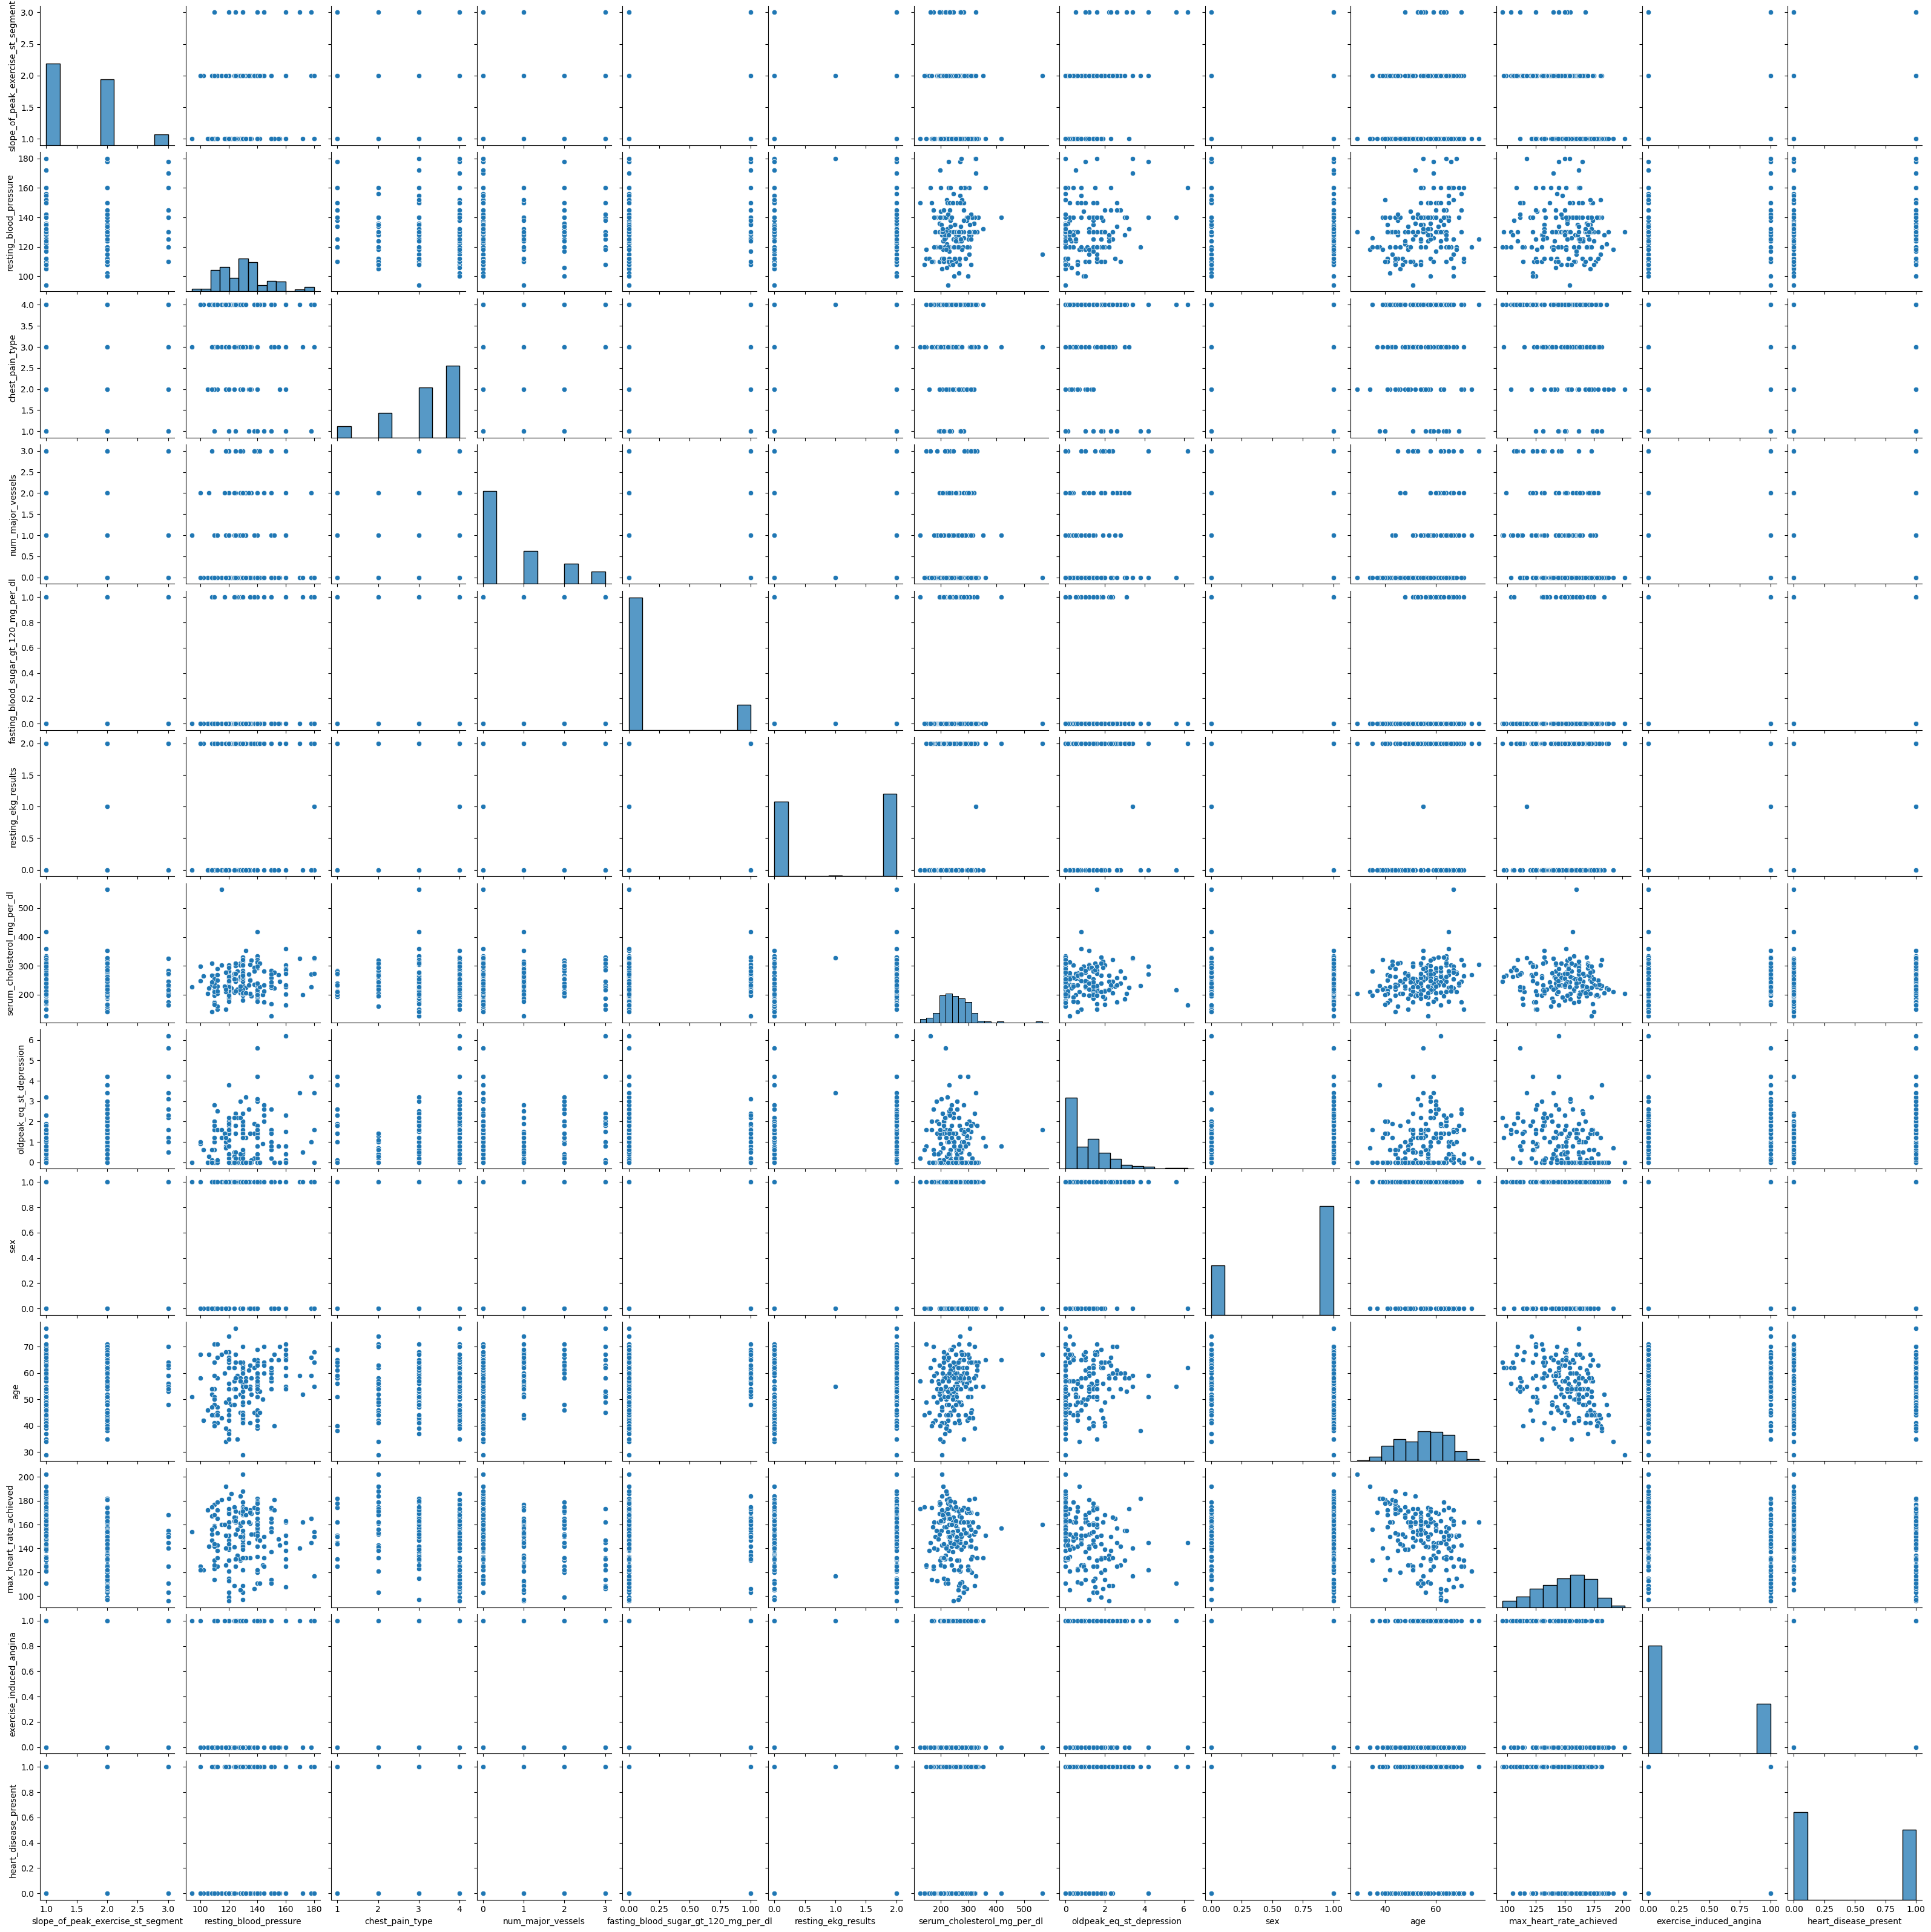

In [4]:
sns.pairplot(df)

In [9]:
df.head() 

,patient_id,slope_of_peak_exercise_st_segment,thal,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
0,0z64un,1,normal,128,2,0,0,2,308,0.0,1,45,170,0,0
1,ryoo3j,2,normal,110,3,0,0,0,214,1.6,0,54,158,0,0
2,yt1s1x,1,normal,125,4,3,0,2,304,0.0,1,77,162,1,1
3,l2xjde,1,reversible_defect,152,4,0,0,0,223,0.0,1,40,181,0,1
4,oyt4ek,3,reversible_defect,178,1,0,0,2,270,4.2,1,59,145,0,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   patient_id                            180 non-null    object 
 1   slope_of_peak_exercise_st_segment     180 non-null    int64  
 2   thal                                  180 non-null    object 
 3   resting_blood_pressure                180 non-null    int64  
 4   chest_pain_type                       180 non-null    int64  
 5   num_major_vessels                     180 non-null    int64  
 6   fasting_blood_sugar_gt_120_mg_per_dl  180 non-null    int64  
 7   resting_ekg_results                   180 non-null    int64  
 8   serum_cholesterol_mg_per_dl           180 non-null    int64  
 9   oldpeak_eq_st_depression              180 non-null    float64
 10  sex                                   180 non-null    int64  
 11  age                

In [4]:
df.describe()

,slope_of_peak_exercise_st_segment,resting_blood_pressure,chest_pain_type,num_major_vessels,fasting_blood_sugar_gt_120_mg_per_dl,resting_ekg_results,serum_cholesterol_mg_per_dl,oldpeak_eq_st_depression,sex,age,max_heart_rate_achieved,exercise_induced_angina,heart_disease_present
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,1.550000,131.311111,3.155556,0.694444,0.161111,1.050000,249.211111,1.010000,0.688889,54.811111,149.483333,0.316667,0.444444
std,0.618838,17.010443,0.938454,0.969347,0.368659,0.998742,52.717969,1.121357,0.464239,9.334737,22.063513,0.466474,0.498290
min,1.000000,94.000000,1.000000,0.000000,0.000000,0.000000,126.000000,0.000000,0.000000,29.000000,96.000000,0.000000,0.000000
25%,1.000000,120.000000,3.000000,0.000000,0.000000,0.000000,213.750000,0.000000,0.000000,48.000000,132.000000,0.000000,0.000000
50%,1.000000,130.000000,3.000000,0.000000,0.000000,2.000000,245.500000,0.800000,1.000000,55.000000,152.000000,0.000000,0.000000
75%,2.000000,140.000000,4.000000,1.000000,0.000000,2.000000,281.250000,1.600000,1.000000,62.000000,166.250000,1.000000,1.000000
max,3.000000,180.000000,4.000000,3.000000,1.000000,2.000000,564.000000,6.200000,1.000000,77.000000,202.000000,1.000000,1.000000


In [8]:
df.isnull().sum()

patient_id                              0
slope_of_peak_exercise_st_segment       0
thal                                    0
resting_blood_pressure                  0
chest_pain_type                         0
num_major_vessels                       0
fasting_blood_sugar_gt_120_mg_per_dl    0
resting_ekg_results                     0
serum_cholesterol_mg_per_dl             0
oldpeak_eq_st_depression                0
sex                                     0
age                                     0
max_heart_rate_achieved                 0
exercise_induced_angina                 0
heart_disease_present                   0
dtype: int64

### Target distribution

Text(0.5, 1.0, 'Target Distribution')

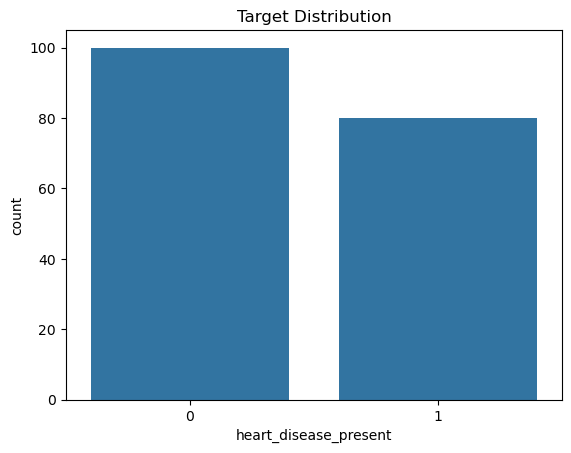

In [10]:
sns.countplot(x='heart_disease_present', data=df)
plt.title("Target Distribution")

### Correlation Analysis

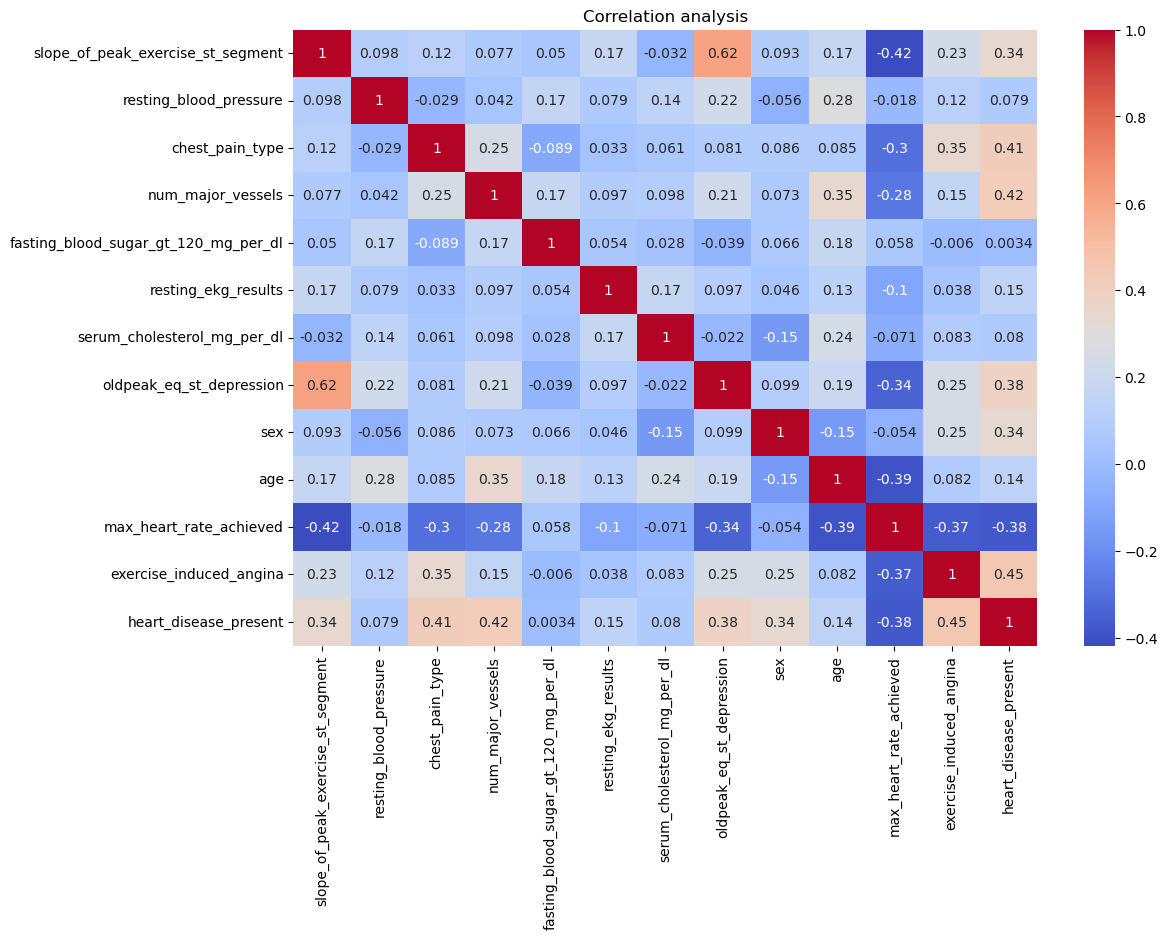

In [11]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation analysis")
plt.show()

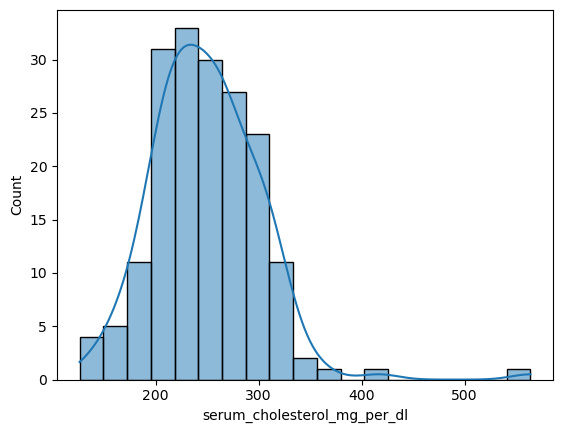

In [12]:
sns.histplot(x='serum_cholesterol_mg_per_dl',kde = True,data=df)
plt.show()

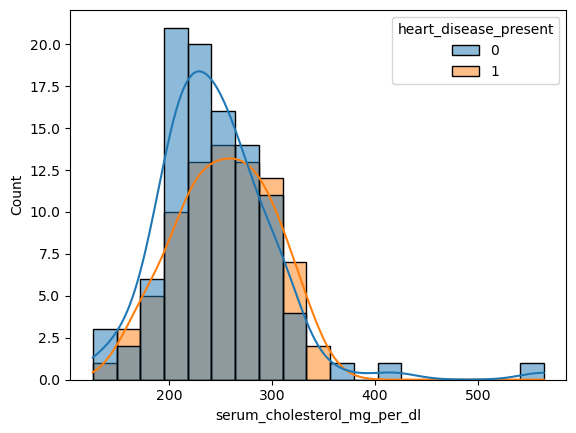

In [4]:
sns.histplot(x='serum_cholesterol_mg_per_dl',kde = True,hue='heart_disease_present',data=df)
plt.show()

In [5]:
numeric_df = df.select_dtypes(include=np.number)
skewness_araay = []
column_names = list(numeric_df.columns)

for column in numeric_df:
    skewness_araay.append(numeric_df[column].skew()) 

In [6]:
skewness_dict = {}
for key,values in zip(column_names,skewness_araay):
    skewness_dict[key] = values

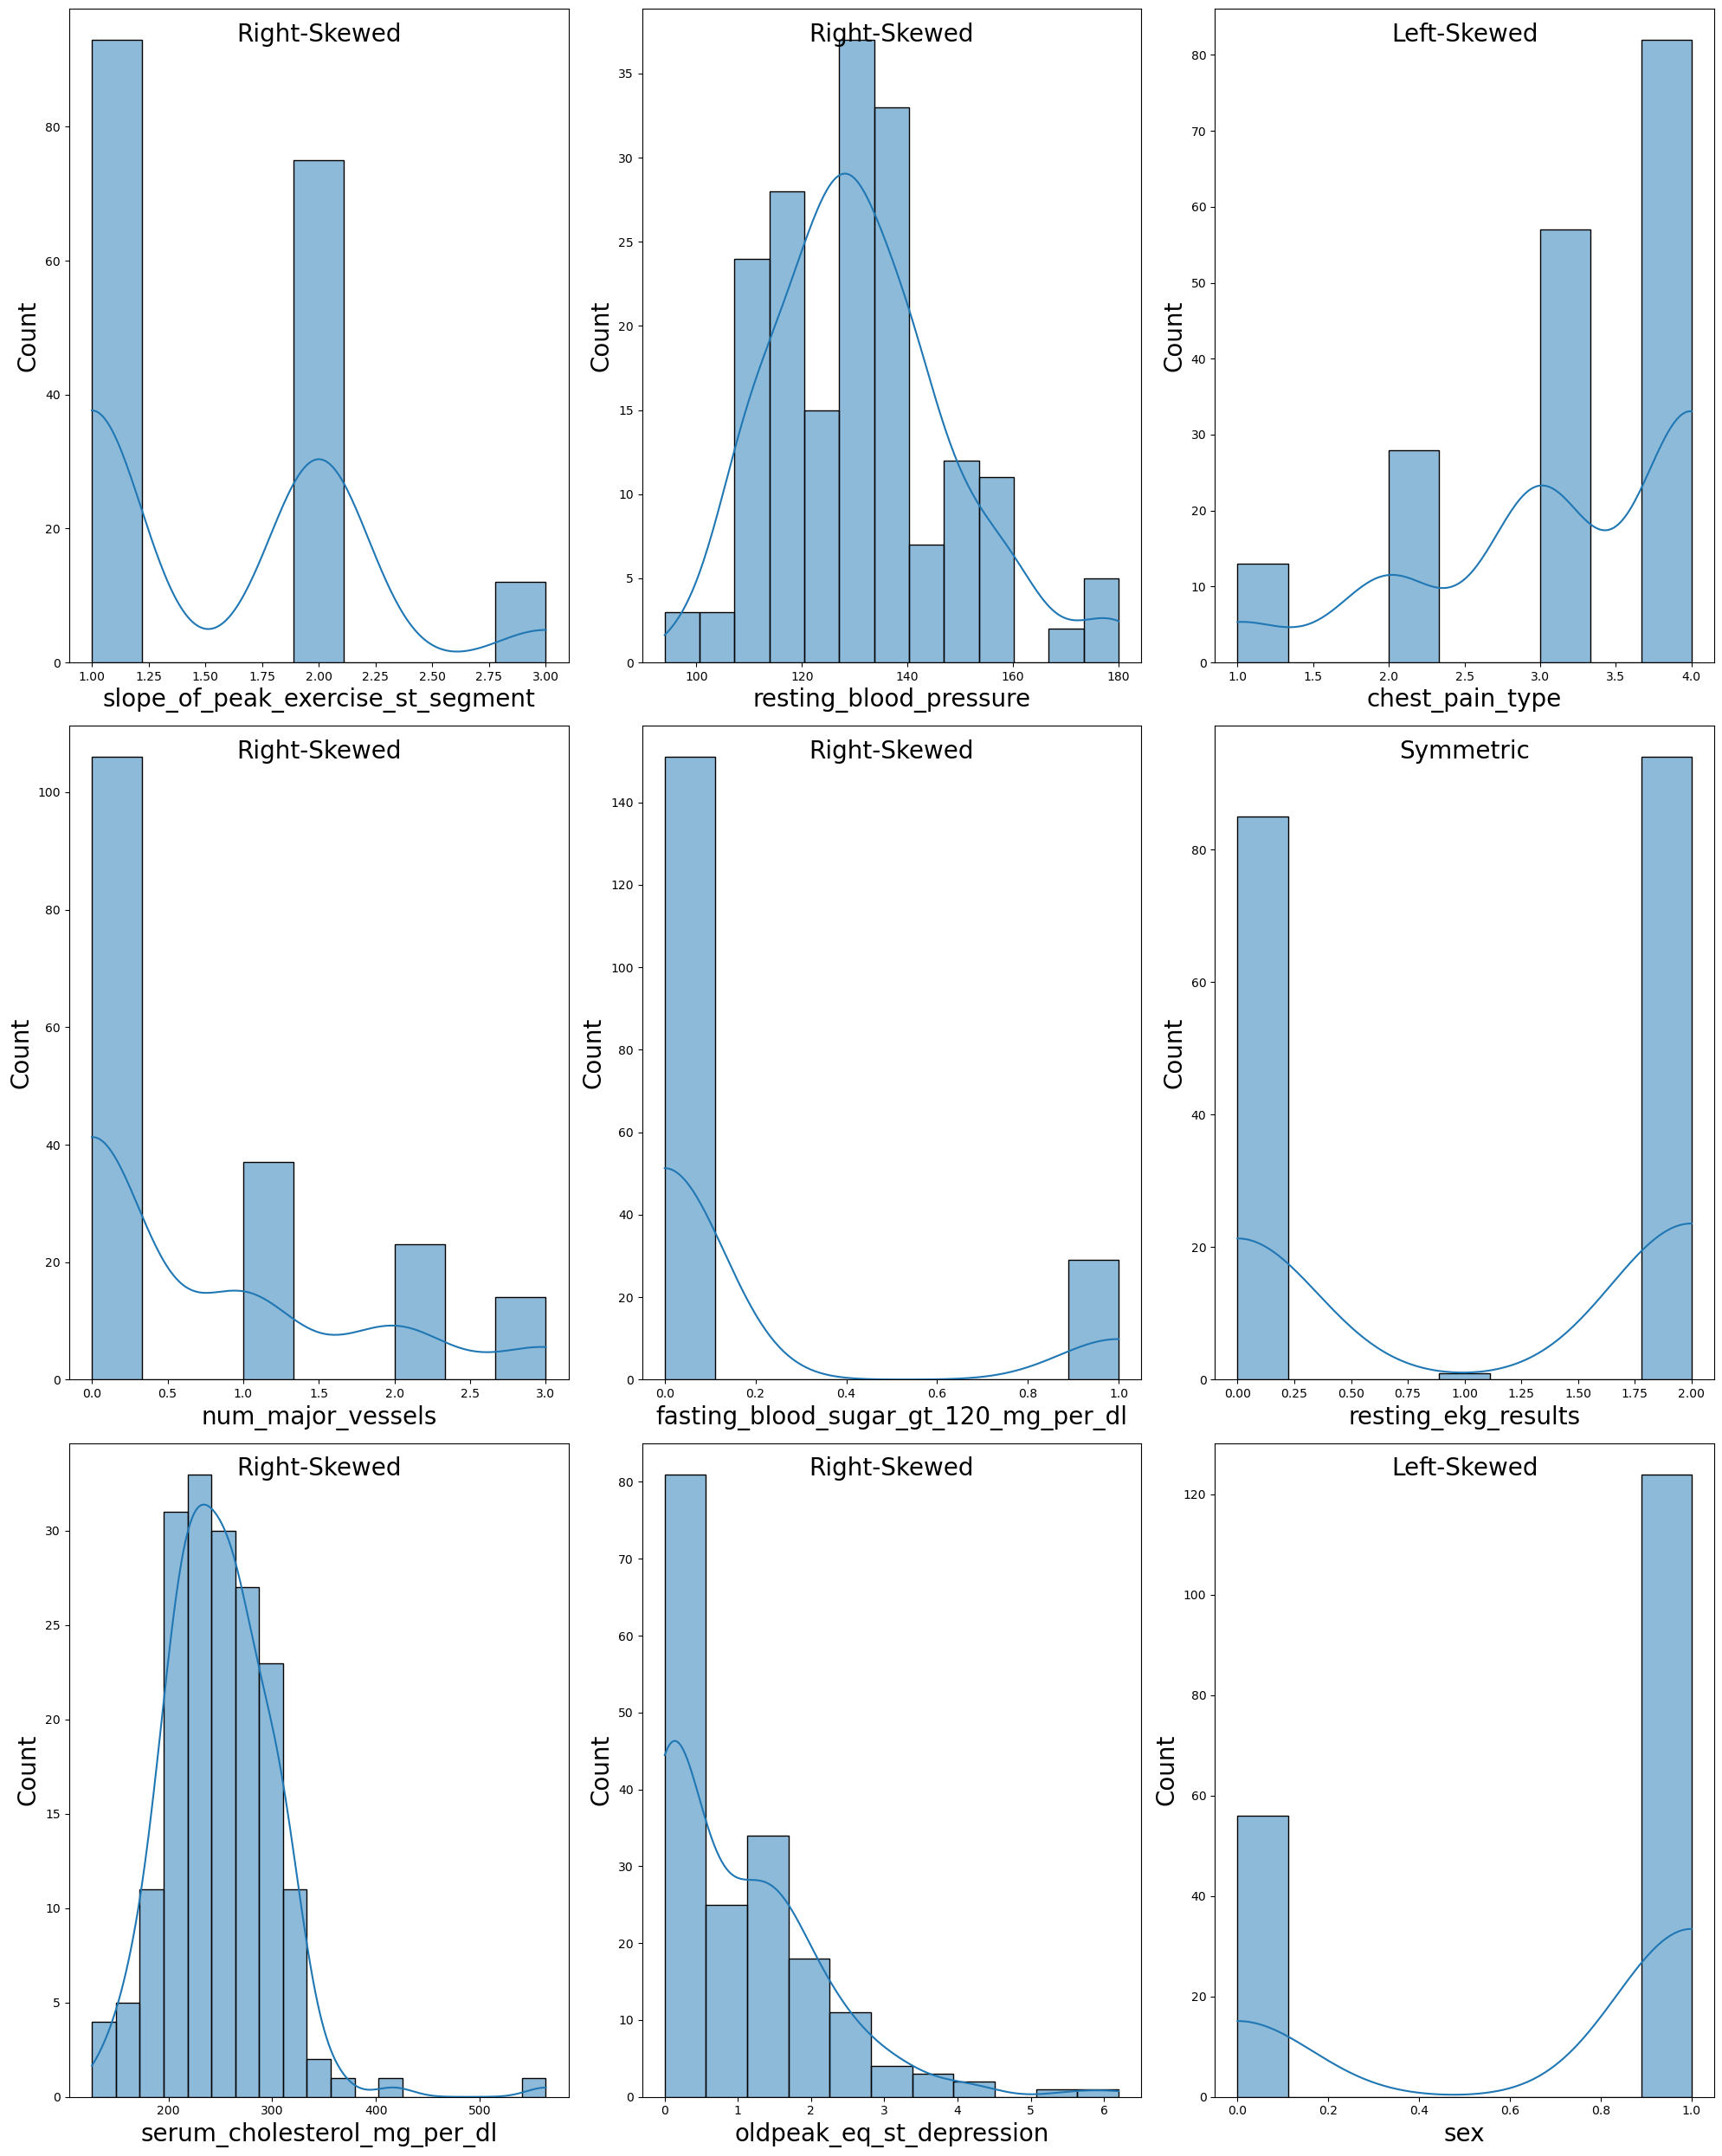

In [7]:
plt.figure(figsize=(20,25),facecolor='White')
plotnumber = 1

for column in numeric_df:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.histplot(numeric_df[column],kde=True)

        #Condition for checking the Skewness
        if skewness_dict.get(column) > 0.5 :
            sentence = 'Right-Skewed'
        elif skewness_dict.get(column) < -0.5 :
            sentence = 'Left-Skewed'
        else:
            sentence = 'Symmetric'
            
        #Text for Showing the Skewness in the Chart
        ax.text(
                0.5, 0.95,
                sentence,
                transform=ax.transAxes,
                ha='center',
                fontsize=20
                )
        
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    plotnumber+=1
plt.tight_layout()

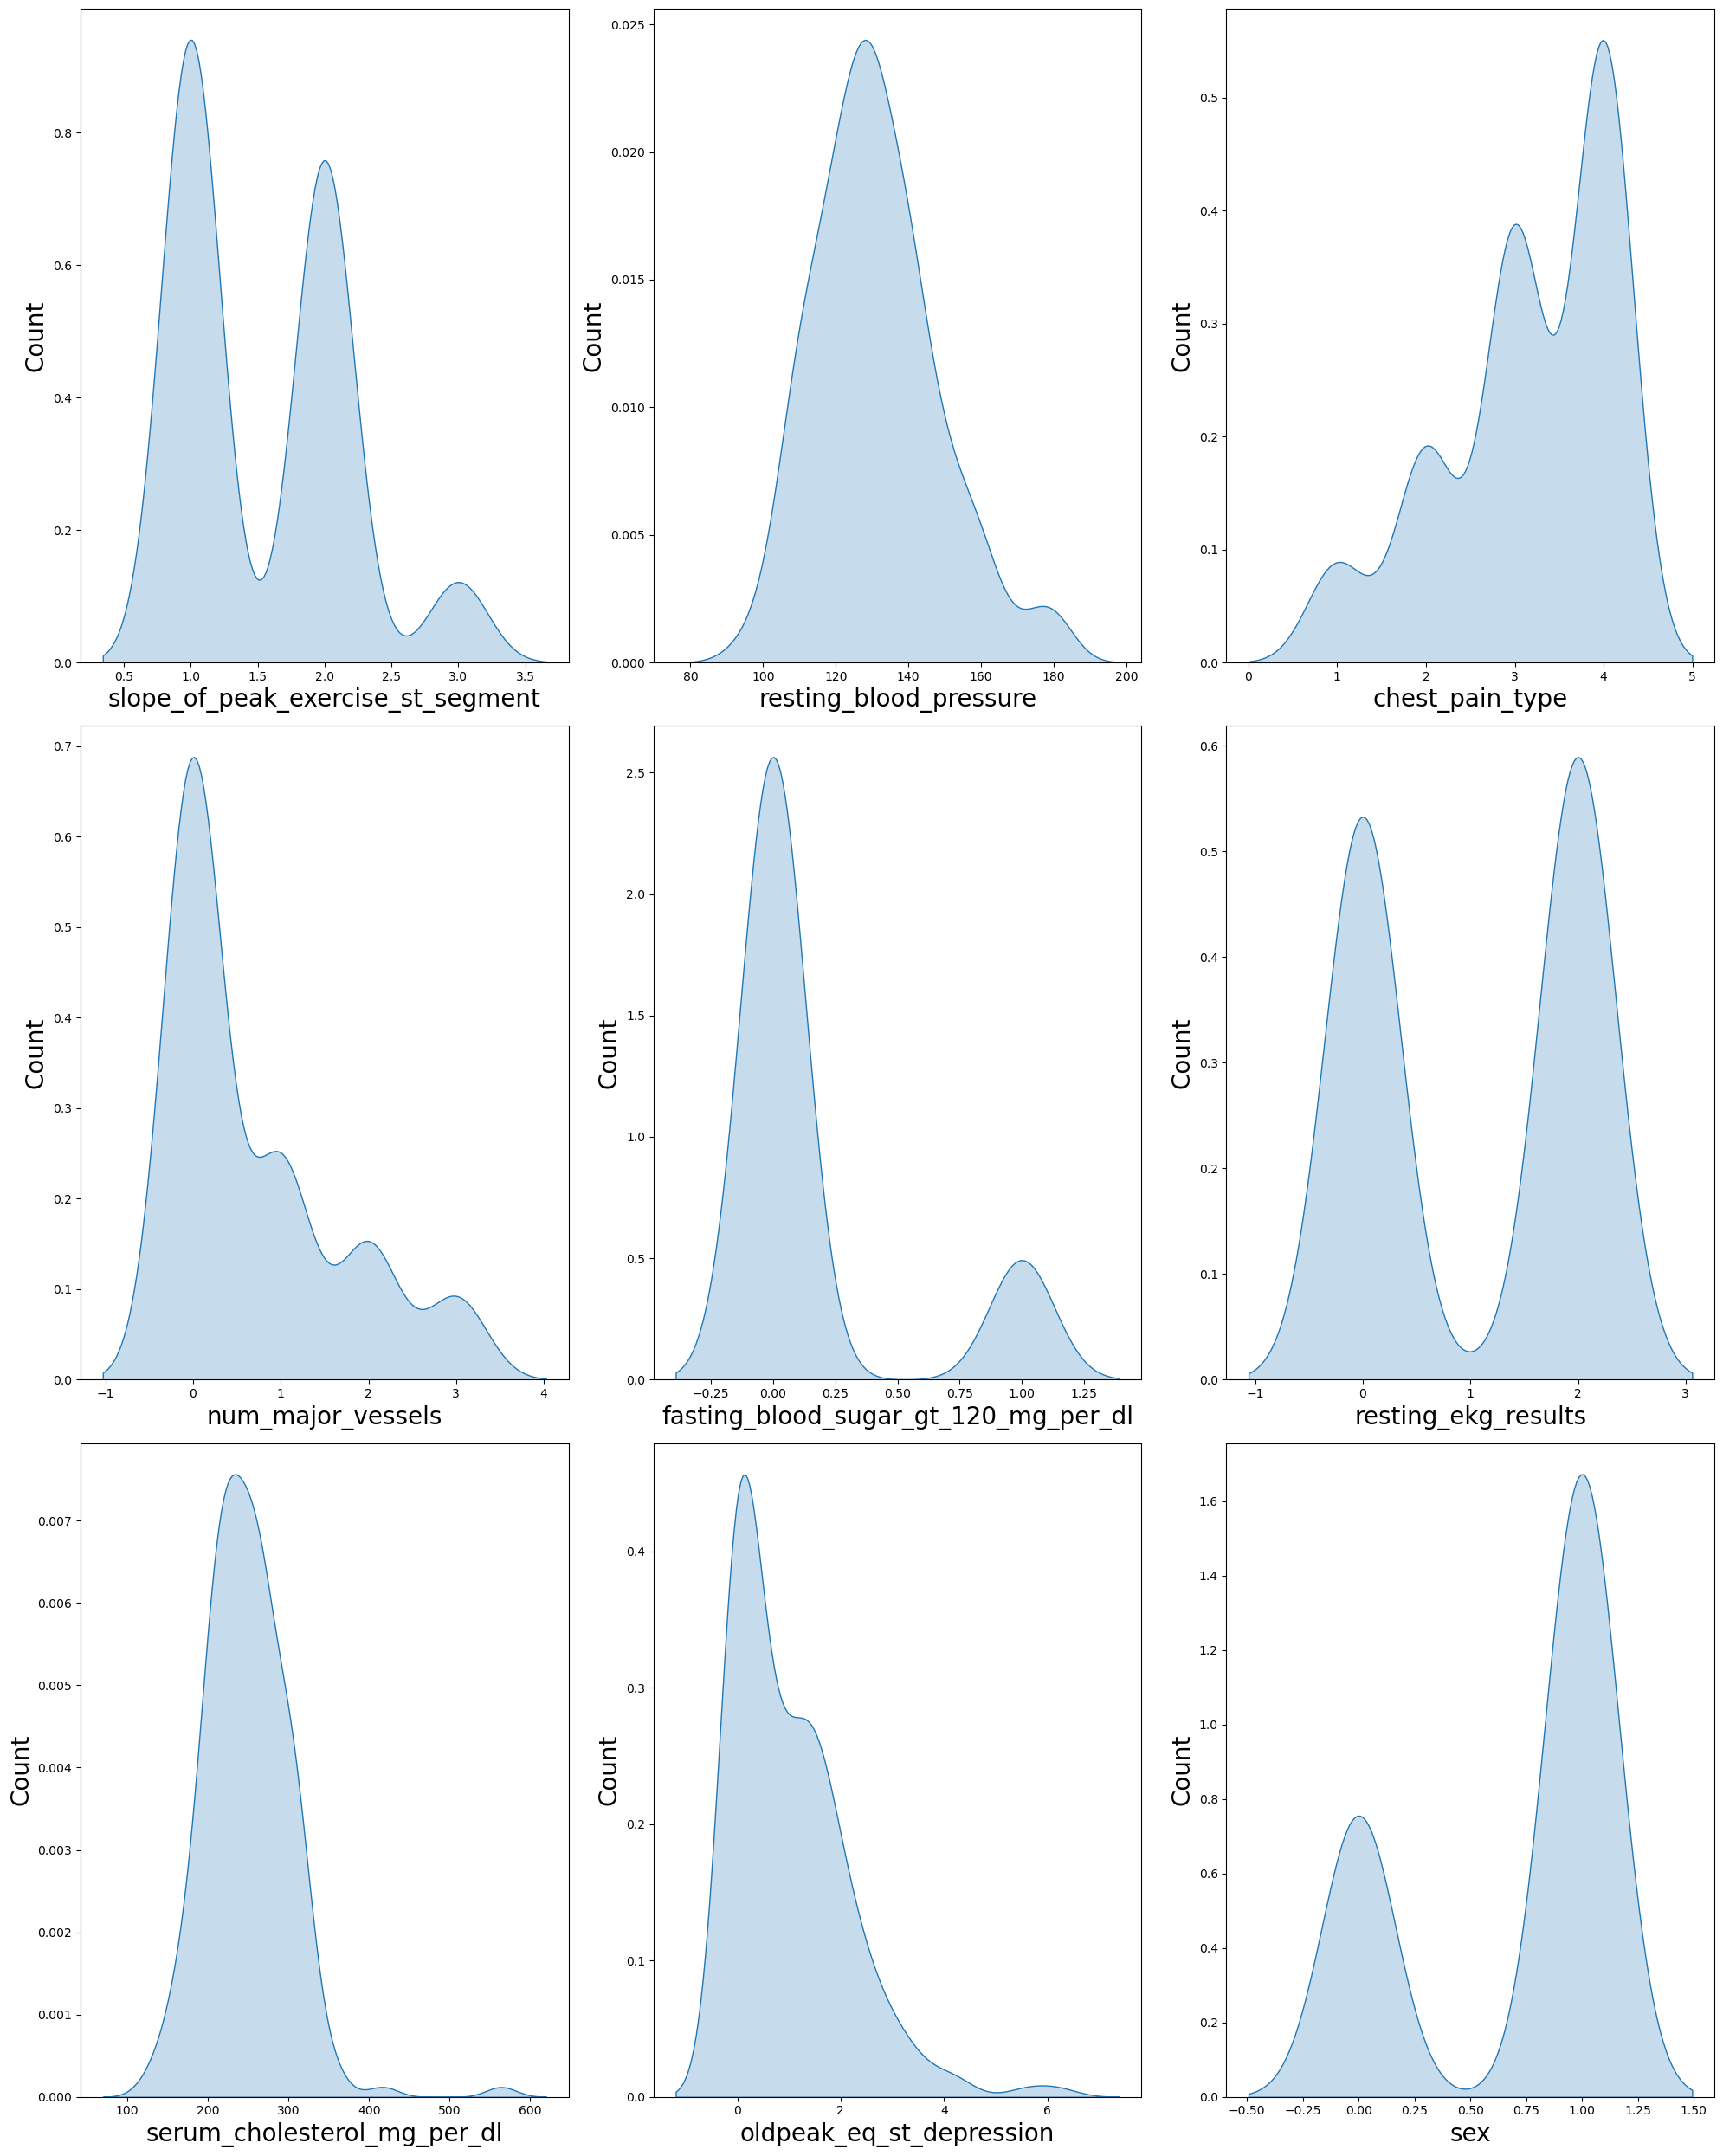

In [8]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber = 1

for column in numeric_df:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.kdeplot(numeric_df[column],fill=True)
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    plotnumber+=1
plt.tight_layout()

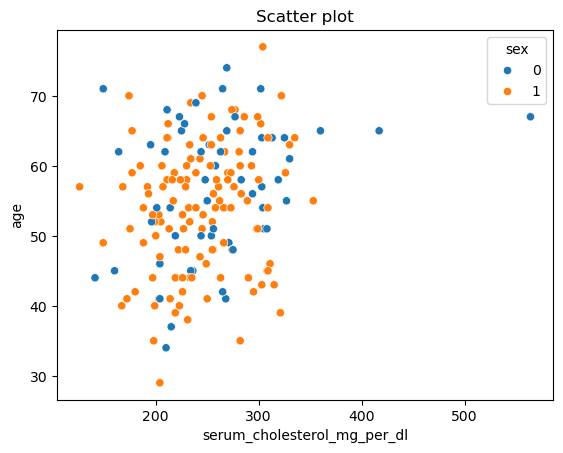

In [20]:
sns.scatterplot(x='serum_cholesterol_mg_per_dl',y='age',data=df, hue='sex')
plt.title("Scatter plot")
plt.show()

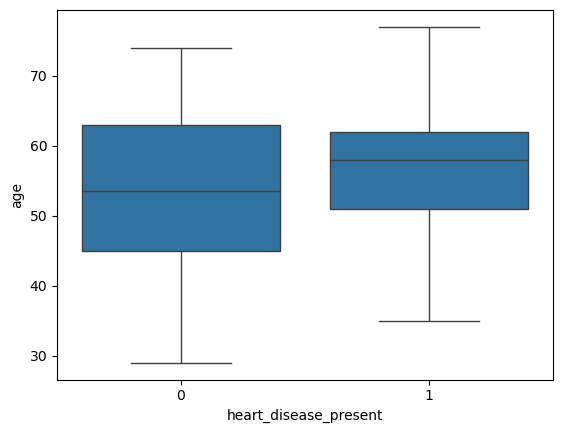

In [26]:
sns.boxplot(x='heart_disease_present', y='age', data=df)
plt.show()

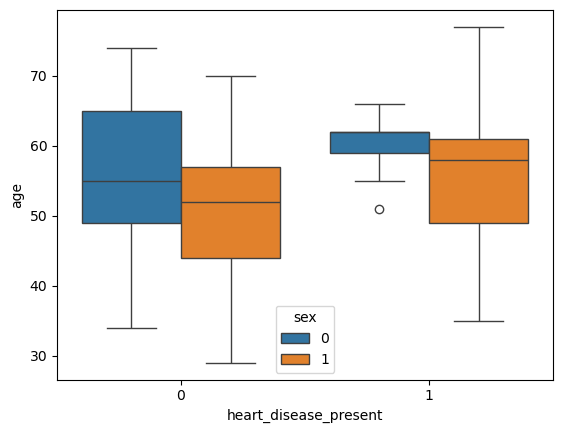

In [27]:
sns.boxplot(x='heart_disease_present', y='age',hue = 'sex', data=df)
plt.show()

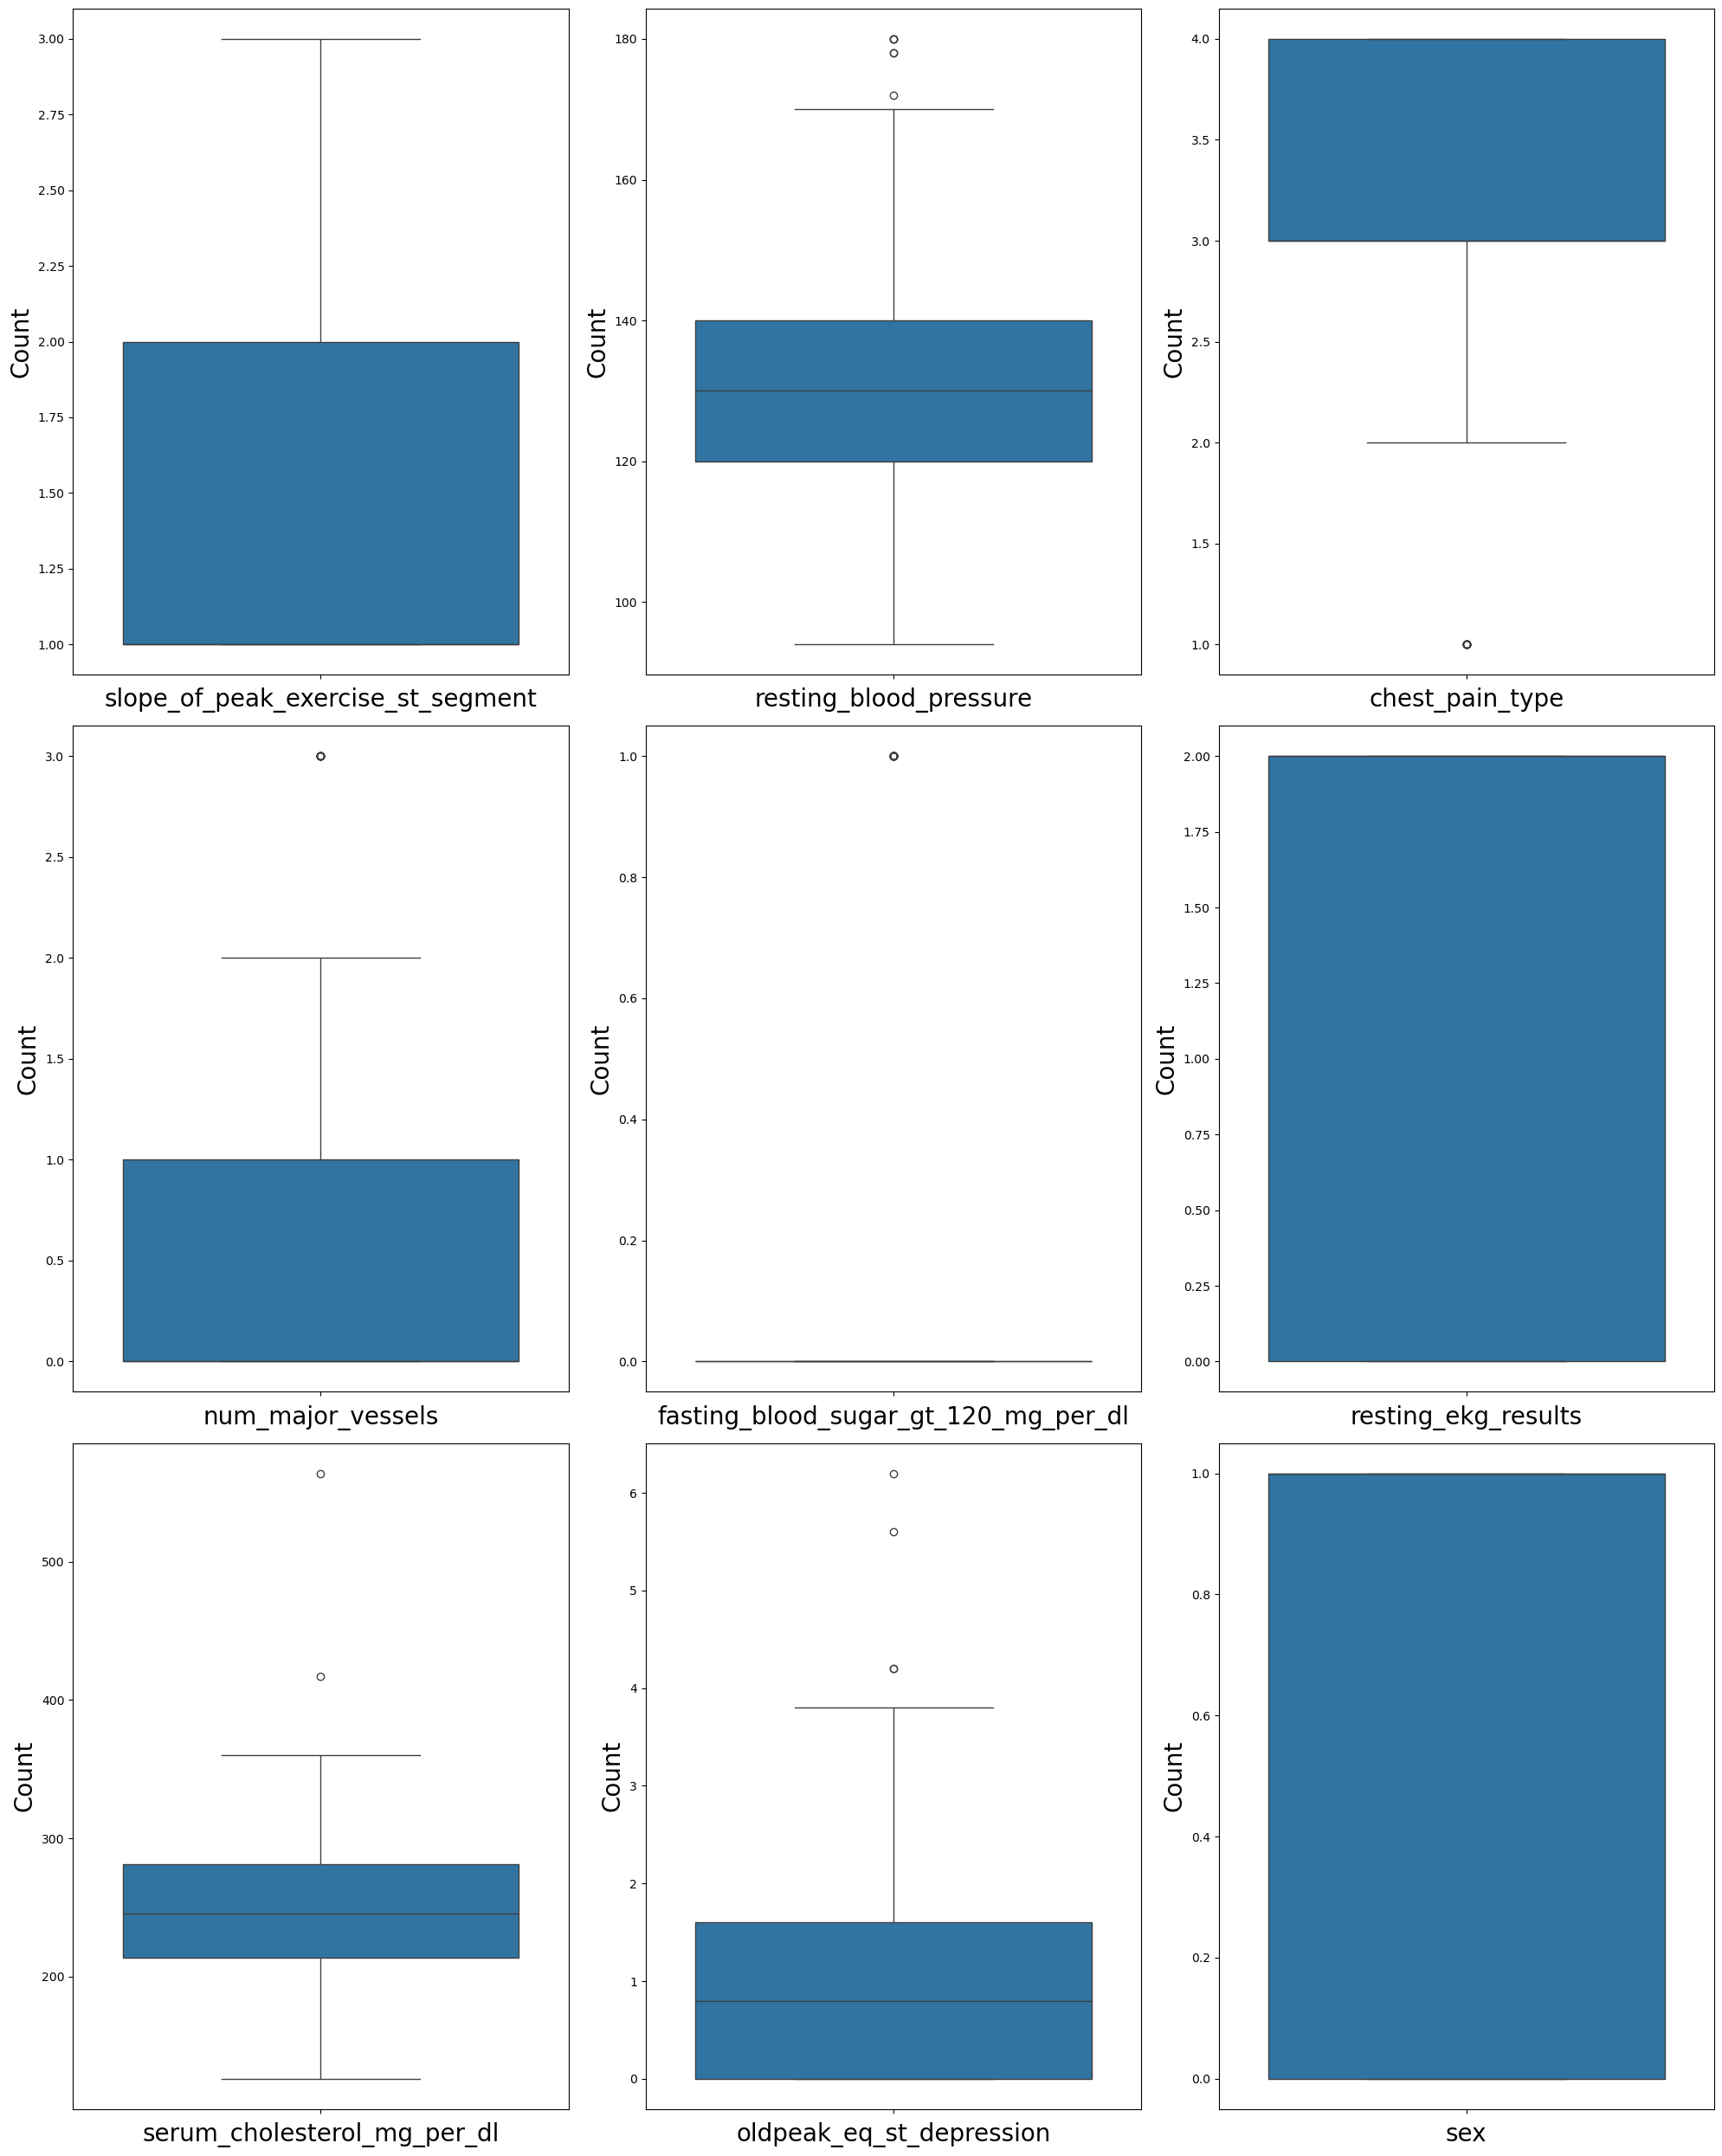

In [9]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber = 1

for column in numeric_df:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.boxplot(numeric_df[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    plotnumber+=1
plt.tight_layout()

### Bivarient Analysis

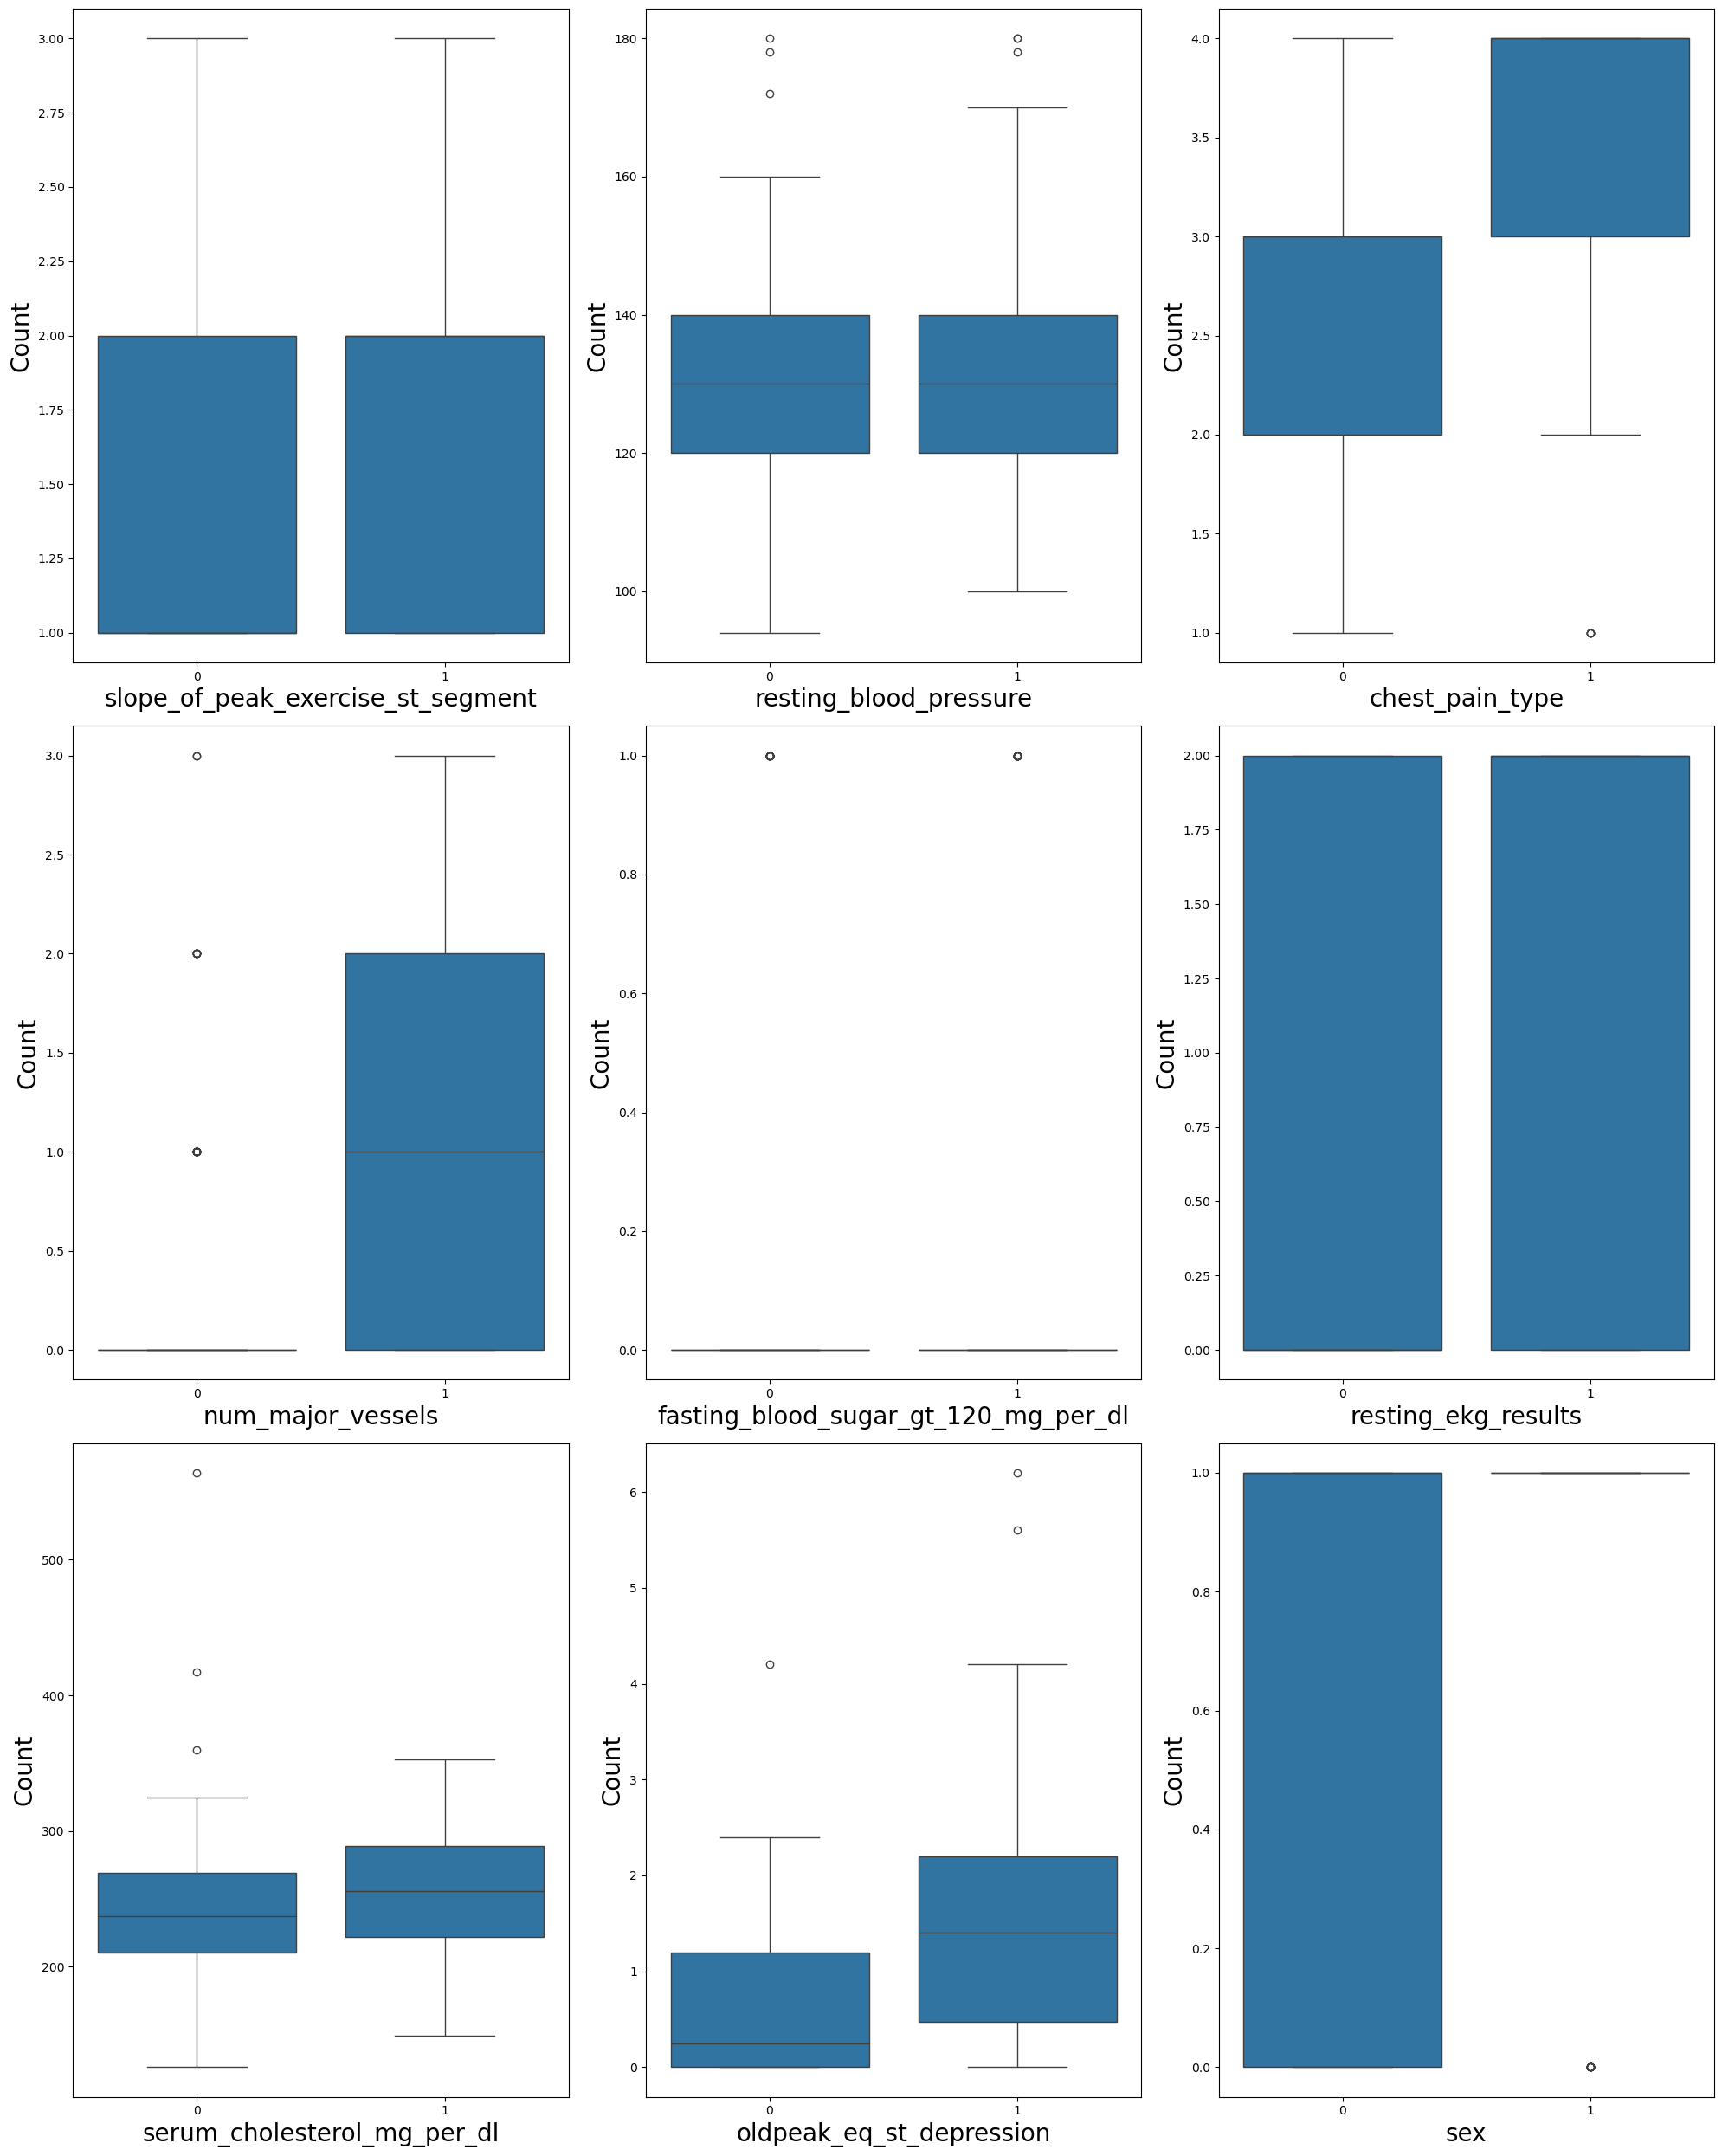

In [11]:
plt.figure(figsize=(20,25),facecolor='white')
plotnumber = 1

for column in numeric_df:
    if plotnumber<=9:
        ax=plt.subplot(3,3,plotnumber)
        sns.boxplot(x = 'heart_disease_present',
                    y = column,
                    data=numeric_df)
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count',fontsize=20)
    plotnumber+=1
plt.tight_layout()

### Outlier Detection 

In [12]:
Q1 = numeric_df.quantile(0.25)

Q3 = numeric_df.quantile(0.75)

IQR = Q3 - Q1

In [13]:
outliers = (
    (numeric_df < (Q1 - 1.5 * IQR)) |
    (numeric_df > (Q3 + 1.5 * IQR))
)

outliers.sum()

slope_of_peak_exercise_st_segment        0
resting_blood_pressure                   6
chest_pain_type                         13
num_major_vessels                       14
fasting_blood_sugar_gt_120_mg_per_dl    29
resting_ekg_results                      0
serum_cholesterol_mg_per_dl              2
oldpeak_eq_st_depression                 4
sex                                      0
age                                      0
max_heart_rate_achieved                  0
exercise_induced_angina                  0
heart_disease_present                    0
dtype: int64

### Age vs Cholesterol

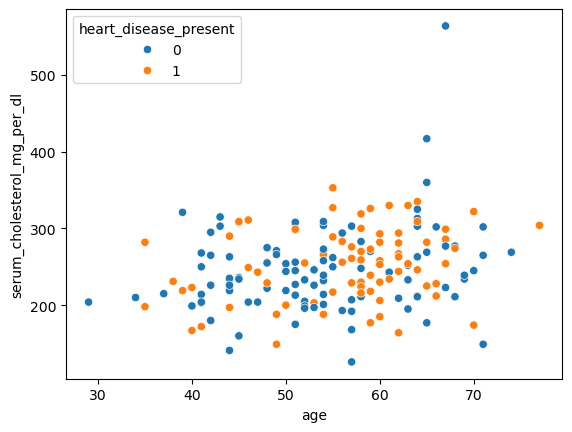

In [14]:
sns.scatterplot(
    x='age',
    y='serum_cholesterol_mg_per_dl',
    hue='heart_disease_present',
    data=df
)

plt.show()

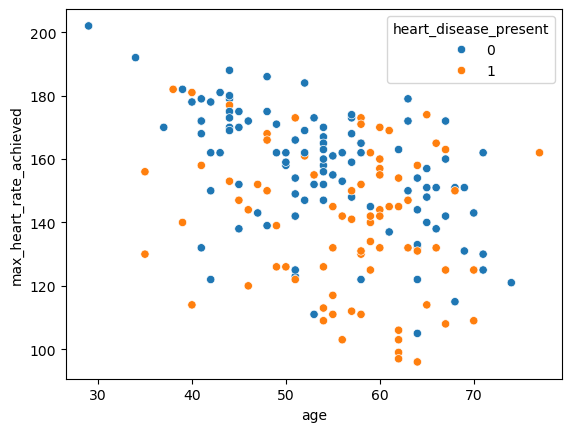

In [15]:
sns.scatterplot(
    x='age',
    y='max_heart_rate_achieved',
    hue='heart_disease_present',
    data=df
)

plt.show()

In [37]:
X = df.drop("heart_disease_present", axis=1)
y = df["heart_disease_present"]

### Machine Learning models

#### Data Processing

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode categorical column
le = LabelEncoder()
df['thal'] = le.fit_transform(df['thal'])

X = df.drop(['heart_disease_present', 'patient_id'], axis=1)
y = df['heart_disease_present']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Model Training

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)

### Scaling the Data

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)


In [38]:
X_train

array([[-0.83939296, -0.59993004, -0.02468392, ..., -1.10628448,
         1.73202176, -0.68511879],
       [-0.83939296, -0.59993004, -0.14940269, ..., -1.00324116,
         0.91144044, -0.68511879],
       [ 0.79402037, -0.59993004, -1.27187163, ...,  0.95458182,
        -0.27384369,  1.4596009 ],
       ...,
       [ 0.79402037,  1.16312967, -0.64827777, ...,  0.74849519,
        -2.14294558, -0.68511879],
       [-0.83939296, -0.59993004, -1.14715286, ..., -1.10628448,
         0.13644697, -0.68511879],
       [ 0.79402037,  1.16312967, -0.9600747 , ...,  1.26371176,
         0.45556193, -0.68511879]])

In [39]:
y_train

139    0
0      0
169    0
65     1
98     0
      ..
179    0
69     1
48     1
153    1
60     0
Name: heart_disease_present, Length: 144, dtype: int64

### Data Preprocessing

In [20]:
thal_column = ["thal"]
numeric_features = [
    "age",
    "resting_blood_pressure",
    "serum_cholesterol_mg_per_dl",
    "max_heart_rate_achieved",
    "oldpeak_eq_st_depression"
]
passthrough_features = [
    "sex",
    "chest_pain_type",
    "fasting_blood_sugar_gt_120_mg_per_dl",
    "resting_ekg_results",
    "exercise_induced_angina",
    "slope_of_peak_exercise_st_segment",
    "num_major_vessels"
]

In [23]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[

        # Encode thal column
        ("thal_encoder", OneHotEncoder(), thal_column),

        # Scale numeric columns
        ("num_scaler", StandardScaler(), numeric_features),

        # Keep remaining columns unchanged
        ("pass", "passthrough", passthrough_features)

    ]
)

In [28]:
lr_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("classifier", LogisticRegression())

])

In [29]:
rf_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("classifier", RandomForestClassifier(
        random_state=42
    ))

])

In [30]:
svm_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("classifier", SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ))

])

In [31]:
gb_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("classifier", GradientBoostingClassifier(
        random_state=42
    ))

])

In [32]:
knn_pipeline = Pipeline(steps=[

    ("preprocessor", preprocessor),

    ("classifier", KNeighborsClassifier(
        n_neighbors=5
    ))

])

In [34]:
models = {

    "Logistic Regression": lr_pipeline,

    "Random Forest": rf_pipeline,

    "SVM": svm_pipeline,

    "Gradient Boosting": gb_pipeline,

    "KNN":knn_pipeline

}

### Model Training 

In [44]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.datasets import make_classification

# Create sample data (replace this with your actual dataset)
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define models dictionary (add your actual models here)
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'SVM': SVC(probability=True, random_state=42),  # probability=True needed for predict_proba
    "Gradient Boosting":GradientBoostingClassifier(
        random_state=42)
    
}

results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Probability predictions
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

# Create DataFrame from results
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0        Random Forest     0.900   0.948454  0.859813  0.901961  0.937946
1  Logistic Regression     0.855   0.914894  0.803738  0.855721  0.921616
2                  SVM     0.845   0.895833  0.803738  0.847291  0.923726
3    Gradient Boosting     0.915   0.968750  0.869159  0.916256  0.934780


In [46]:
model_percent = {k: round(v * 100, 2) for k, v in results_df.items()}
model_percent

{'Model': 0    Random ForestRandom ForestRandom ForestRandom ...
 1    Logistic RegressionLogistic RegressionLogistic...
 2    SVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMSVMS...
 3    Gradient BoostingGradient BoostingGradient Boo...
 Name: Model, dtype: object,
 'Accuracy': 0    90.0
 1    85.5
 2    84.5
 3    91.5
 Name: Accuracy, dtype: float64,
 'Precision': 0    94.85
 1    91.49
 2    89.58
 3    96.88
 Name: Precision, dtype: float64,
 'Recall': 0    85.98
 1    80.37
 2    80.37
 3    86.92
 Name: Recall, dtype: float64,
 'F1 Score': 0    90.20
 1    85.57
 2    84.73
 3    91.63
 Name: F1 Score, dtype: float64,
 'ROC-AUC': 0    93.79
 1    92.16
 2    92.37
 3    93.48
 Name: ROC-AUC, dtype: float64}

### Model Comparison

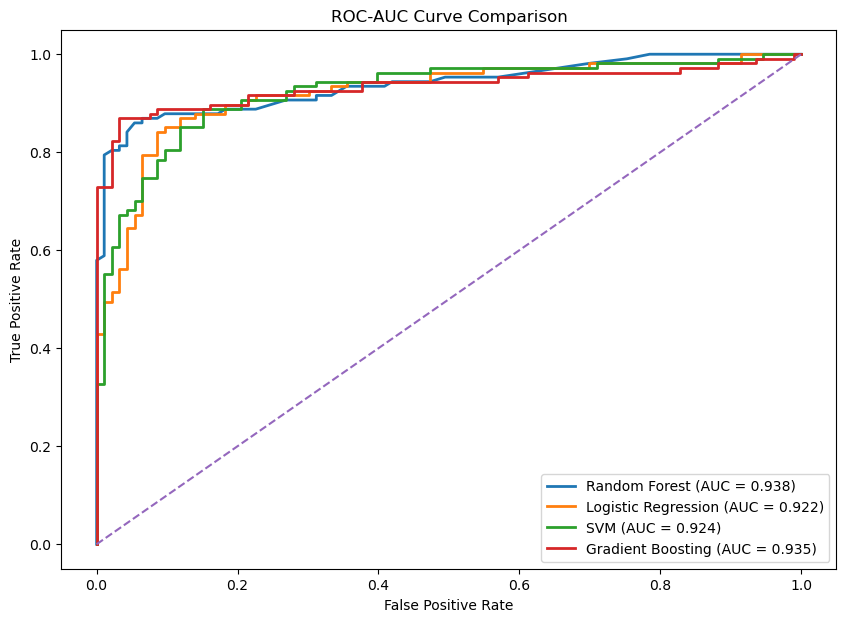

In [47]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Create ROC Curve Plot
plt.figure(figsize=(10, 7))

for name, model in models.items():

    # Train model
    model.fit(X_train, y_train)

    # Get probability predictions
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate ROC Curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Calculate AUC Score
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# Random Guess Line
plt.plot([0, 1], [0, 1], linestyle='--')

# Labels and Title
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")

# Legend
plt.legend(loc="lower right")

# Show Plot
plt.show()

In [48]:
results = []

for name,model in models.items():
    
    training_acc = model.score(X_train,y_train)
    testing_acc = model.score(X_test,y_test)

    results.append({

        "Model": name,

        "Training Accuracy": training_acc,

        "Testing Accuracy": testing_acc
    })

results_df = pd.DataFrame(results)

print(results_df)  

                 Model  Training Accuracy  Testing Accuracy
0        Random Forest            1.00000             0.900
1  Logistic Regression            0.88250             0.855
2                  SVM            0.92875             0.845
3    Gradient Boosting            0.99000             0.915


### Accuracy test

In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.97      0.91        93
           1       0.97      0.87      0.92       107

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.92       200



### Cross Validation 

In [49]:
from sklearn.model_selection import cross_val_score

cv_results = []

for name, model in models.items():

    scores = cross_val_score(
        model,
        X,
        y,
        cv=10,
        scoring='accuracy'
    )

    cv_results.append({

        "Model": name,

        "CV Mean Accuracy": scores.mean(),

        "CV Std": scores.std()

    })

cv_results_df = pd.DataFrame(cv_results)

print(cv_results_df)

                 Model  CV Mean Accuracy    CV Std
0        Random Forest             0.894  0.025377
1  Logistic Regression             0.869  0.033897
2                  SVM             0.863  0.023259
3    Gradient Boosting             0.911  0.024678


### Conclusion

Although SVM achieved the highest ROC-AUC score, we have selected Gradient Boosting due to its superior recall and F1-score, which are more important in healthcare applications where minimizing false negatives is critical. And also we have got lowest std(cross_val_score) for the Gradient Boosting Model, that means this Model is Most Stable amongst all the Models.

Gradient Boosting:

Accuracy - 0.888
Recall - 0.937
F1 Score - 0.882

